In [1]:
import pandas as pd
import numpy as np
import config as Config
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv(r'D:\Projects2025\song_recommendation\data\raw\spotify_tracks.csv')
print(f"loaded {len(df)} tracks \n")
print(f"total columns {len(df.columns)}")
print(f"{df['track_genre'].nunique()} genres")
print(df[['track_name', 'artists', 'popularity']].head(10))
features = ['danceability','energy', 'valence','tempo']
print(df[features].describe())

loaded 114000 tracks 

total columns 21
114 genres
                   track_name                               artists  \
0                      Comedy                           Gen Hoshino   
1            Ghost - Acoustic                          Ben Woodward   
2              To Begin Again                Ingrid Michaelson;ZAYN   
3  Can't Help Falling In Love                          Kina Grannis   
4                     Hold On                      Chord Overstreet   
5        Days I Will Remember                          Tyrone Wells   
6               Say Something  A Great Big World;Christina Aguilera   
7                   I'm Yours                            Jason Mraz   
8                       Lucky             Jason Mraz;Colbie Caillat   
9                      Hunger                        Ross Copperman   

   popularity  
0          73  
1          55  
2          57  
3          71  
4          82  
5          58  
6          74  
7          80  
8          74  
9      

In [29]:
print(df['track_genre'].value_counts())

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64


In [3]:
print("missing values", df.isnull().sum())
print("\n")
print("data types",df.dtypes)

missing values Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


data types Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             f

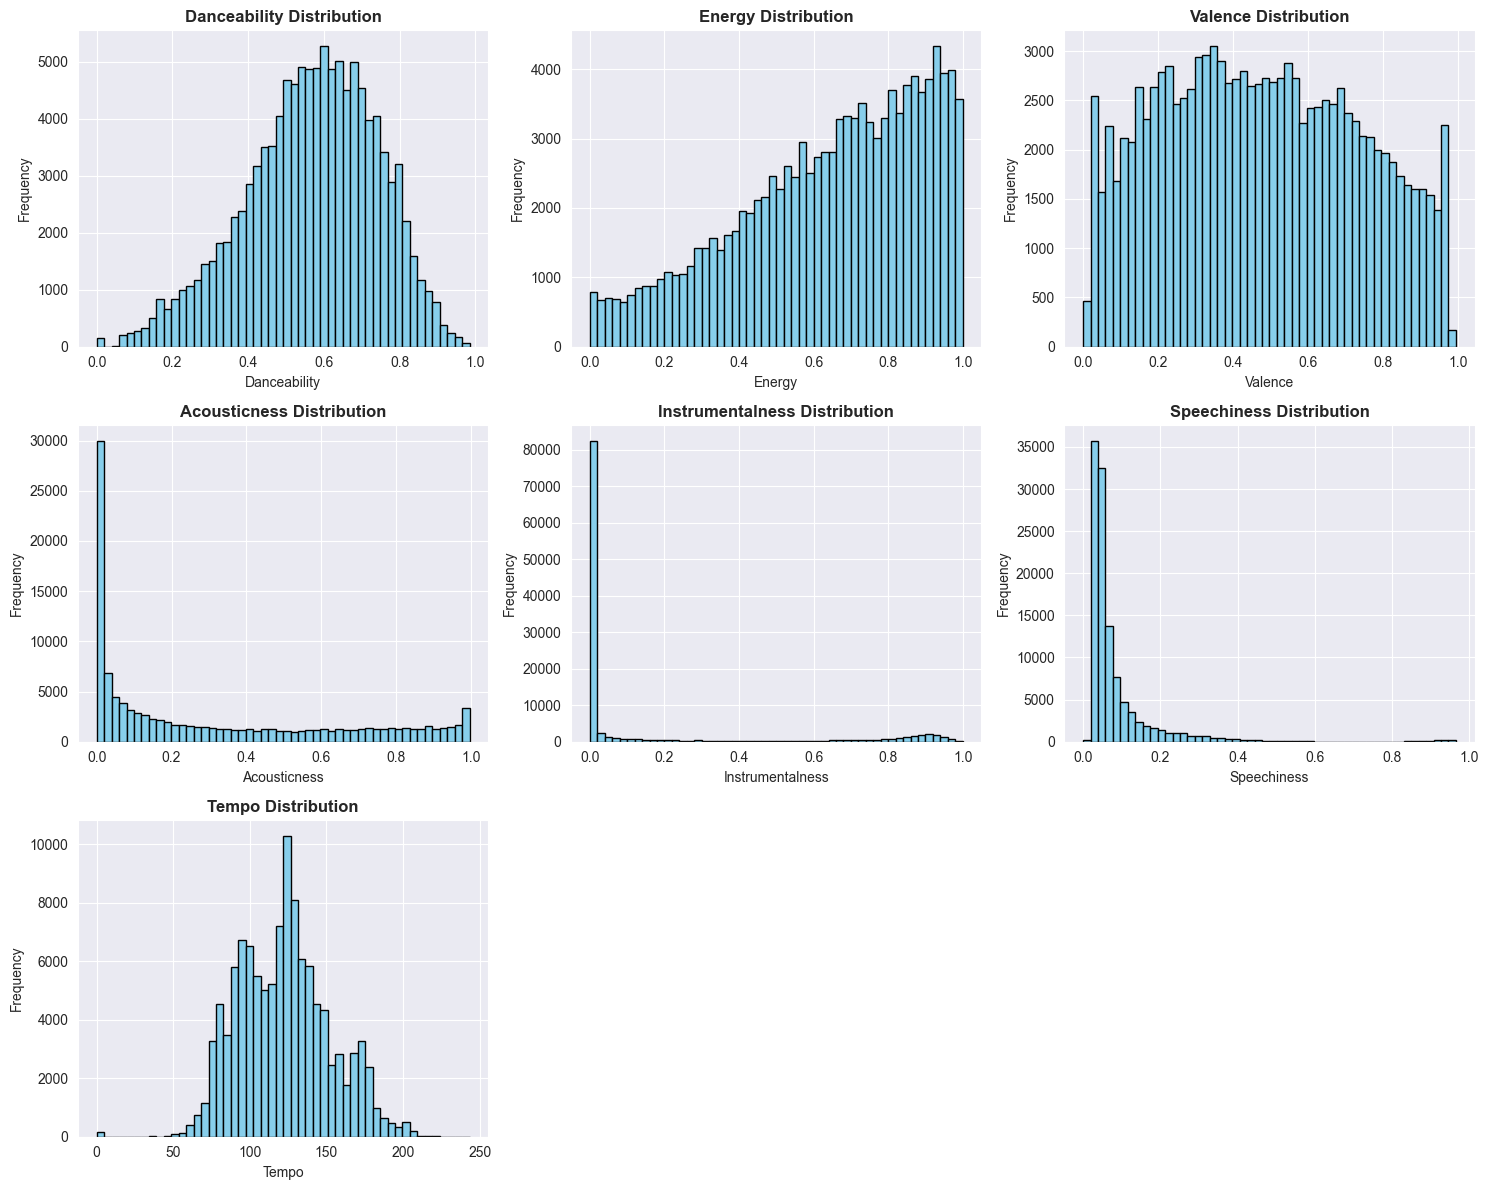

In [4]:
audio_features = ['danceability', 'energy', 'valence', 'acousticness', 
                  'instrumentalness', 'speechiness', 'tempo']
fig,axes = plt.subplots(3,3,figsize = (15,12))
axes = axes.flatten()
for idx,feature in enumerate(audio_features):
    if feature in df.columns:
        axes[idx].hist(df[feature], bins = 50, color = 'skyblue', edgecolor = 'black')
        axes[idx].set_title(f'{feature.title()} Distribution', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(feature.title())
        axes[idx].set_ylabel('Frequency')
for idx in range(len(audio_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

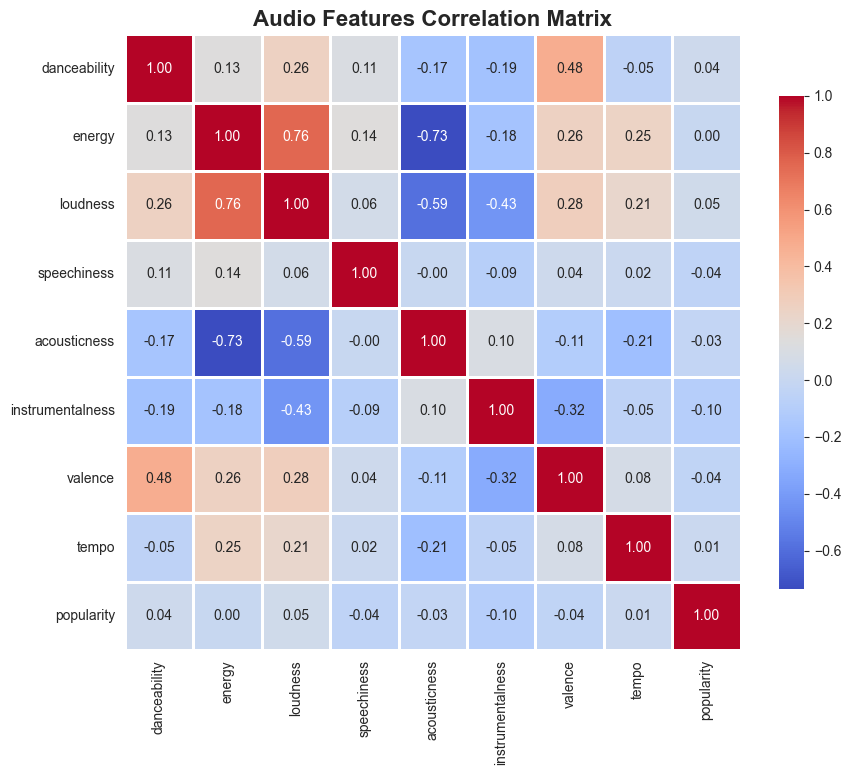


Key insights:
- Energy & Loudness correlation: 0.76
- Energy & Acousticness correlation: -0.73


In [5]:
features_for_corr = ['danceability', 'energy', 'loudness', 'speechiness',
                     'acousticness', 'instrumentalness', 'valence', 'tempo', 'popularity']

plt.figure(figsize=(10, 8))
correlation_matrix = df[features_for_corr].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Audio Features Correlation Matrix', fontsize=16, fontweight='bold')
plt.show()

print("\nKey insights:")
print(f"- Energy & Loudness correlation: {correlation_matrix.loc['energy', 'loudness']:.2f}")
print(f"- Energy & Acousticness correlation: {correlation_matrix.loc['energy', 'acousticness']:.2f}")

- The above graph represents the linear relations between different features
- uses pearson correlation (ranges from -1 to +1)
  - +1 perfect positive relation
  - 0 no linear relationship
  - -1 perfect negative relation
- diagonals are always 1 (ignore them)
- Energy & Loudness → Strong Positive (≈ 0.76)
Meaning   - Louder songs tend to be more energetic
- Energy & Acousticness → Strong Negative (≈ -0.73)
Meaning   - Acoustic songs are usually calm
          - Energetic songs are usually electronic / amplified
- Danceability & Valence → Moderate Positive (≈ 0.48)
Meaning - Happier songs are often more danceable

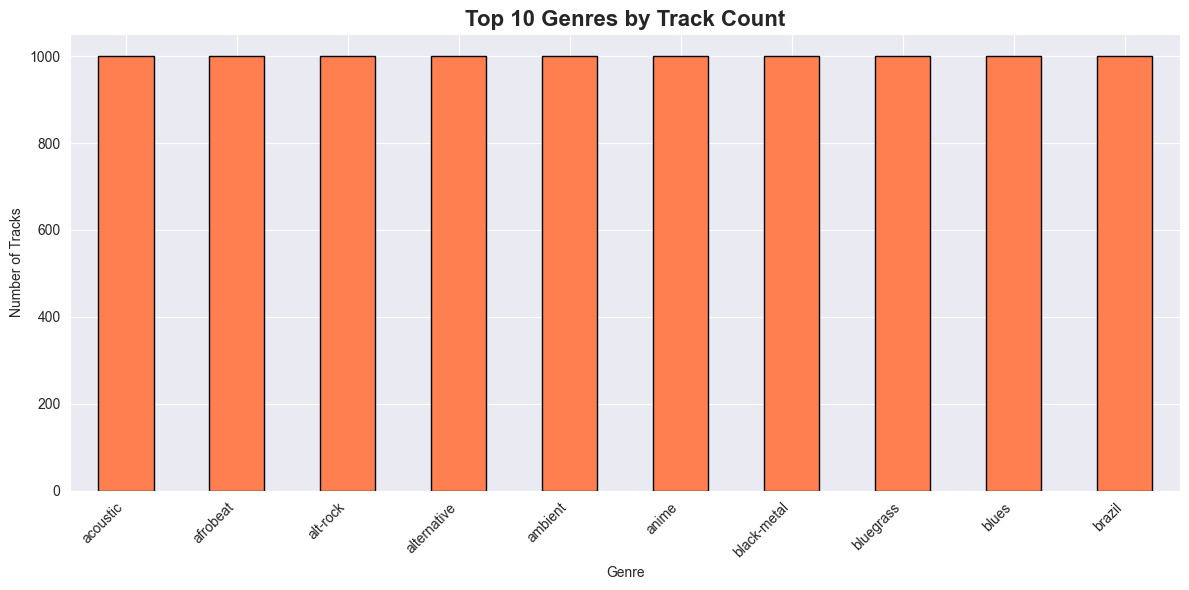

Total genres: 114


In [6]:
top_genres = df['track_genre'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_genres.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 Genres by Track Count', fontsize=16, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total genres: {df['track_genre'].nunique()}")

- The bar chart shows the top 10 genres by track count. 
- The distribution is nearly uniform, with each genre contributing approximately the same number of tracks.
- This indicates a balanced dataset with no dominant genre, which is beneficial for training unbiased recommendation models.
- The dataset contains a total of 114 unique genres, reflecting high musical diversity.

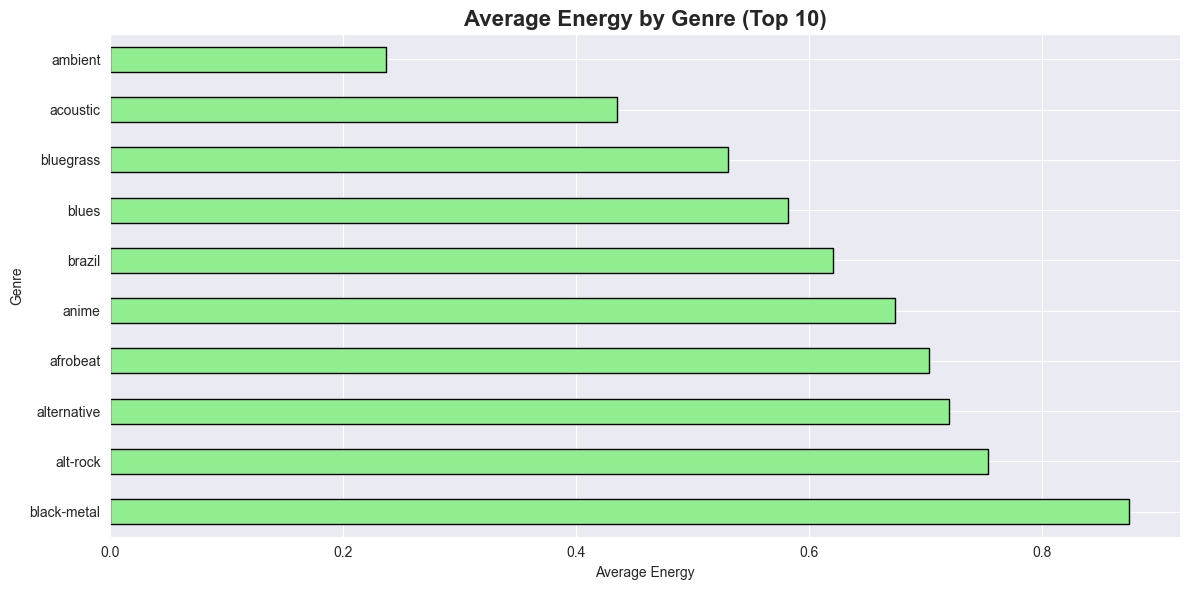

In [7]:
top_10_genres = df['track_genre'].value_counts().head(10).index
genre_energy = df[df['track_genre'].isin(top_10_genres)].groupby('track_genre')['energy'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
genre_energy.plot(kind='barh', color='lightgreen', edgecolor='black')
plt.title('Average Energy by Genre (Top 10)', fontsize=16, fontweight='bold')
plt.xlabel('Average Energy')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

- The analysis shows a clear variation in energy levels across genres. 
- Heavy genres like black-metal and alt-rock exhibit the highest average energy.
- Acoustic and ambient genres have significantly lower energy.

Based on these insights, our recommendation system can:
Match by mood - Use valence (happiness) and energy
Match by vibe - Use acousticness and instrumentalness
Match by genre - Filter within similar genres
Match by danceability - For workout/party playlists

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

def create_complex_user_interactions(df, n_interactions=10000):
    np.random.seed(42)
    user_profiles = {
        'energetic_morning': {
            'energy': 0.9, 'danceability': 0.8, 'valence': 0.9, 
            'tempo': 0.85
        },
        'chill_evening': {
            'acousticness': 0.9, 'energy': 0.2, 'instrumentalness': 0.7,
            'valence': 0.3
        },
        'party_weekend': {
            'danceability': 1.0, 'energy': 0.95, 'valence': 0.9,
            'loudness': 0.9, 'speechiness': 0.3
        },
        'sad_rainy': {
            'valence': 0.1, 'acousticness': 0.8, 'energy': 0.2,
            'instrumentalness': 0.6, 'tempo': 0.3
        },
        'workout_intense': {
            'energy': 1.0, 'tempo': 1.0, 'loudness': 0.95,
            'danceability': 0.8, 'instrumentalness': 0.2
        },
        'focus_work': {
            'instrumentalness': 0.9, 'speechiness': 0.05, 'energy': 0.4,
            'acousticness': 0.6, 'valence': 0.5
        },
        'romantic_dinner': {
            'valence': 0.6, 'acousticness': 0.7, 'energy': 0.3,
            'danceability': 0.4, 'speechiness': 0.2
        },
        'nostalgic_throwback': {
            'valence': 0.5, 'acousticness': 0.5, 'energy': 0.6,
            'danceability': 0.6, 'tempo': 0.5
        },
        'experimental_indie': {
            'instrumentalness': 0.6, 'acousticness': 0.4, 'energy': 0.5,
            'danceability': 0.5, 'speechiness': 0.1
        },
        'hype_pregame': {
            'energy': 0.95, 'loudness': 0.9, 'valence': 0.85,
            'danceability': 0.9, 'tempo': 0.8
        }
    }
    
    interactions = []
    
    print(f"Simulating {len(user_profiles)} diverse user types...")
    print(f"Generating {n_interactions} complex interactions...\n")
    
    for _ in range(n_interactions):
        profile_type = np.random.choice(list(user_profiles.keys()))
        profile = user_profiles[profile_type]
        
        song_idx = np.random.randint(0, len(df))
        song = df.iloc[song_idx]
        
        rating = 0.3
        
        for feature, preferred_value in profile.items():
            if feature in song.index:
                if feature == 'tempo':
                    song_value = song[feature] / 200.0
                elif feature == 'loudness':
                    song_value = (song[feature] + 60) / 60.0
                else:
                    song_value = song[feature]
                
                similarity = 1 - abs(preferred_value - song_value)
                if profile_type in ['workout_intense', 'party_weekend']:
                    if feature == 'energy':
                        similarity *= 1.5
                elif profile_type in ['chill_evening', 'focus_work']:
                    if feature == 'acousticness':
                        similarity *= 1.5
                
                rating += similarity * 0.08
        
        genre_bonus = 0
        if 'track_genre' in song.index:
            genre = song['track_genre']
            if profile_type == 'party_weekend' and genre in ['edm', 'dance', 'pop']:
                genre_bonus = 0.15
            elif profile_type == 'chill_evening' and genre in ['acoustic', 'indie', 'folk']:
                genre_bonus = 0.15
            elif profile_type == 'workout_intense' and genre in ['rock', 'metal', 'hip-hop']:
                genre_bonus = 0.15
        
        rating += genre_bonus
        
        user_consistency = np.random.uniform(0.7, 1.0)
        noise = np.random.normal(0, 0.15) * (1 - user_consistency)
        rating += noise
        
        if np.random.random() < 0.05:
            rating += np.random.uniform(0.1, 0.3)
        
        if np.random.random() < 0.05:
            rating -= np.random.uniform(0.1, 0.3)
        
        rating = np.clip(rating, 0, 1)
        
        interaction = {
            'user_profile': profile_type,
            'song_idx': song_idx,
            'track_name': song['track_name'],
            'artists': song['artists'],
            'danceability': song['danceability'],
            'energy': song['energy'],
            'valence': song['valence'],
            'acousticness': song['acousticness'],
            'instrumentalness': song['instrumentalness'],
            'speechiness': song['speechiness'],
            'tempo_normalized': song['tempo'] / 200.0,
            'loudness_normalized': (song['loudness'] + 60) / 60.0,
            'rating': rating
        }
        interactions.append(interaction)
    
    interactions_df = pd.DataFrame(interactions)
    
    print(f"Created {len(interactions_df)} user interactions")
    print(f"User profiles: {len(user_profiles)}")
    print(f"\n Rating distribution:")
    print(interactions_df['rating'].describe())
    print(f"\nInteractions per user type:")
    print(interactions_df['user_profile'].value_counts())
    
    return interactions_df

In [9]:
interactions_df_complex = create_complex_user_interactions(df, n_interactions=10000)

Simulating 10 diverse user types...
Generating 10000 complex interactions...

Created 10000 user interactions
User profiles: 10

 Rating distribution:
count    10000.000000
mean         0.577432
std          0.094873
min          0.102697
25%          0.528691
50%          0.585052
75%          0.626852
max          1.000000
Name: rating, dtype: float64

Interactions per user type:
user_profile
hype_pregame           1098
romantic_dinner        1020
focus_work             1012
chill_evening          1011
nostalgic_throwback    1004
party_weekend           993
experimental_indie      980
workout_intense         969
energetic_morning       962
sad_rainy               951
Name: count, dtype: int64


In [10]:
def create_interaction_features(interactions_df):
    interactions_df['energy_dance'] = interactions_df['energy'] * interactions_df['danceability']
    
    interactions_df['acoustic_energy_ratio'] = interactions_df['acousticness'] / (interactions_df['energy'] + 0.01)
    
    interactions_df['mood_score'] = interactions_df['valence'] * interactions_df['energy']
    
    interactions_df['chill_score'] = interactions_df['acousticness'] * (1 - interactions_df['energy'])
    
    print("Created 4 interaction features:")
    print("  - energy_dance")
    print("  - acoustic_energy_ratio")
    print("  - mood_score")
    print("  - chill_score")
    
    return interactions_df

interactions_df_complex = create_interaction_features(interactions_df_complex)

Created 4 interaction features:
  - energy_dance
  - acoustic_energy_ratio
  - mood_score
  - chill_score


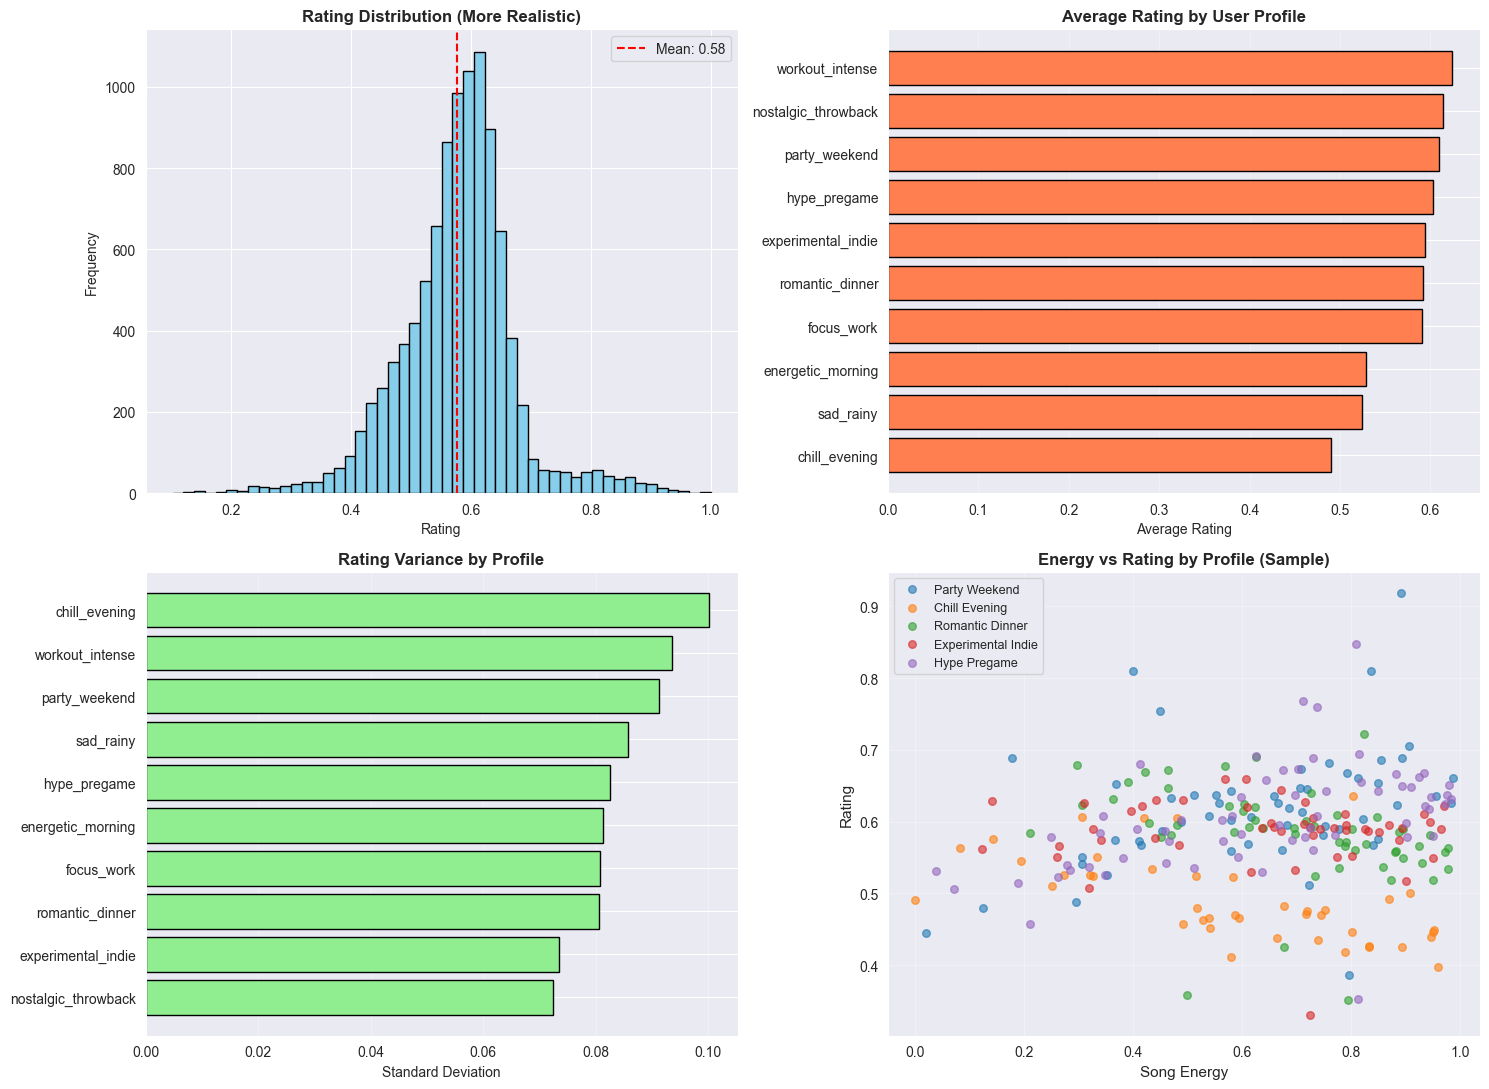


Visualizations complete!

Data Summary:
  Total interactions: 10,000
  Rating range: 0.10 - 1.00
  Rating mean: 0.58
  Rating std dev: 0.09


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

axes[0, 0].hist(interactions_df_complex['rating'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Rating Distribution (More Realistic)', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(interactions_df_complex['rating'].mean(), color='red', 
                   linestyle='--', label=f'Mean: {interactions_df_complex["rating"].mean():.2f}')
axes[0, 0].legend()

profile_ratings = interactions_df_complex.groupby('user_profile')['rating'].mean().sort_values()
axes[0, 1].barh(profile_ratings.index, profile_ratings.values, color='coral', edgecolor='black')
axes[0, 1].set_title('Average Rating by User Profile', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Average Rating')
axes[0, 1].grid(True, alpha=0.3, axis='x')

profile_variance = interactions_df_complex.groupby('user_profile')['rating'].std().sort_values()
axes[1, 0].barh(profile_variance.index, profile_variance.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Rating Variance by Profile', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Standard Deviation')
axes[1, 0].grid(True, alpha=0.3, axis='x')

sample = interactions_df_complex.sample(500, random_state=42)
profiles = sample['user_profile'].unique()[:5]  

for profile in profiles:
    profile_data = sample[sample['user_profile'] == profile]
    axes[1, 1].scatter(profile_data['energy'], profile_data['rating'], 
                      alpha=0.6, s=30, label=profile.replace('_', ' ').title())

axes[1, 1].set_xlabel('Song Energy', fontsize=11)
axes[1, 1].set_ylabel('Rating', fontsize=11)
axes[1, 1].set_title('Energy vs Rating by Profile (Sample)', fontweight='bold', fontsize=12)
axes[1, 1].legend(loc='best', fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualizations complete!")
print(f"\nData Summary:")
print(f"  Total interactions: {len(interactions_df_complex):,}")
print(f"  Rating range: {interactions_df_complex['rating'].min():.2f} - {interactions_df_complex['rating'].max():.2f}")
print(f"  Rating mean: {interactions_df_complex['rating'].mean():.2f}")
print(f"  Rating std dev: {interactions_df_complex['rating'].std():.2f}")

In [12]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

class NeuralRecommender:    
    def __init__(self, use_interaction_features=True):
        base_features = ['danceability', 'energy', 'valence', 'acousticness',
                        'instrumentalness', 'speechiness', 'tempo_normalized', 
                        'loudness_normalized']
        
        interaction_features = ['energy_dance', 'acoustic_energy_ratio', 
                               'mood_score', 'chill_score']
        
        if use_interaction_features:
            self.features = base_features + interaction_features
        else:
            self.features = base_features
            
        self.model = None
        self.scaler = None
        
        print(f"NeuralRecommender initialized with {len(self.features)} features")
    
    def build_models(self):        
        tf.random.set_seed(42)
        models = []
        
        input_dim = len(self.features)
        model_1 = keras.Sequential([
            keras.layers.Dense(32, activation='relu', input_shape=(input_dim,)),
            keras.layers.Dense(16, activation='relu'),
            keras.layers.Dense(1, activation='linear')
        ], name='model_1_simple')
        models.append(model_1)
        
        model_2 = keras.Sequential([
            keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dense(16, activation='relu'),
            keras.layers.Dense(1, activation='linear')
        ], name='model_2_medium')
        models.append(model_2)
        
        model_3 = keras.Sequential([
            keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dense(16, activation='relu'),
            keras.layers.Dense(1, activation='linear')
        ], name='model_3_deep_regularized')
        models.append(model_3)
        
        return models
    

D:\Projects2025\song_recommendation\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [13]:
def train(self, interactions_df):
    X = interactions_df[self.features].values
    y = interactions_df['rating'].values
    
    print(f"Dataset: {len(X):,} samples with {len(self.features)} features")
    from sklearn.model_selection import train_test_split
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    X_cv, X_test, y_cv, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )
    
    print(f"  Training set: {len(X_train):,} samples")
    print(f"  Validation set: {len(X_cv):,} samples")
    print(f"  Test set: {len(X_test):,} samples")
    
    self.scaler = StandardScaler()
    X_train_scaled = self.scaler.fit_transform(X_train)
    X_cv_scaled = self.scaler.transform(X_cv)
    X_test_scaled = self.scaler.transform(X_test)
    
    print("\nFeatures normalized with StandardScaler")
    
    models = self.build_models()
    
    nn_train_mses = []
    nn_cv_mses = []
    histories = []
    
    print(f"\nTraining {len(models)} different architectures...\n")
    
    for model in models:
        model.compile(
            loss='mse',
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
            metrics=['mae']
        )
        
        print(f"Training {model.name}...")
        
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True
        )
        
        history = model.fit(
            X_train_scaled, y_train,
            validation_data=(X_cv_scaled, y_cv),
            epochs=300,
            batch_size=32,
            verbose=0,
            callbacks=[early_stop]
        )
        
        histories.append(history)
        print("  Done!")
        
        yhat_train = model.predict(X_train_scaled, verbose=0)
        train_mse = mean_squared_error(y_train, yhat_train)
        nn_train_mses.append(train_mse)
        
        yhat_cv = model.predict(X_cv_scaled, verbose=0)
        cv_mse = mean_squared_error(y_cv, yhat_cv)
        nn_cv_mses.append(cv_mse)
    
    print("📊 MODEL COMPARISON RESULTS")
    print(f"\n{'Model':<30} {'Train MSE':<15} {'Val MSE':<15} {'Status':<10}")
    
    best_model_idx = np.argmin(nn_cv_mses)
    
    for i, (train_mse, cv_mse) in enumerate(zip(nn_train_mses, nn_cv_mses)):
        status = "BEST" if i == best_model_idx else ""
        print(f"{models[i].name:<30} {train_mse:<15.4f} {cv_mse:<15.4f} {status:<10}")
    
    self.model = models[best_model_idx]
    
    print(f"\nSelected: {self.model.name}")
    
    yhat_test = self.model.predict(X_test_scaled, verbose=0)
    test_mse = mean_squared_error(y_test, yhat_test)
    test_mae = mean_absolute_error(y_test, yhat_test)
    test_r2 = r2_score(y_test, yhat_test)
    
    print(f"\nFINAL TEST SET PERFORMANCE:")
    print(f"  Test MSE: {test_mse:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    
    self._plot_results(models, histories, nn_train_mses, nn_cv_mses, 
                      X_test_scaled, y_test, best_model_idx)
    
    return {
        'best_model': self.model.name,
        'test_mse': test_mse,
        'test_r2': test_r2,
        'train_mses': nn_train_mses,
        'cv_mses': nn_cv_mses
    }

NeuralRecommender.train = train

In [14]:
def _plot_results(self, models, histories, train_mses, cv_mses, 
                 X_test, y_test, best_idx):
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    x = np.arange(len(models))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, train_mses, width, label='Train MSE', color='skyblue', edgecolor='black')
    axes[0, 0].bar(x + width/2, cv_mses, width, label='Validation MSE', color='coral', edgecolor='black')
    axes[0, 0].set_xlabel('Model', fontsize=11)
    axes[0, 0].set_ylabel('MSE', fontsize=11)
    axes[0, 0].set_title('Model Comparison: Train vs Validation MSE', fontweight='bold', fontsize=12)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels([m.name for m in models], rotation=45, ha='right')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    best_history = histories[best_idx]
    axes[0, 1].plot(best_history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0, 1].plot(best_history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('Loss (MSE)', fontsize=11)
    axes[0, 1].set_title(f'Training History: {models[best_idx].name}', fontweight='bold', fontsize=12)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    yhat_test = self.model.predict(X_test, verbose=0).flatten()
    axes[1, 0].scatter(y_test, yhat_test, alpha=0.5, s=20, color='green')
    axes[1, 0].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect Prediction')
    axes[1, 0].set_xlabel('Actual Rating', fontsize=11)
    axes[1, 0].set_ylabel('Predicted Rating', fontsize=11)
    axes[1, 0].set_title('Test Set: Actual vs Predicted', fontweight='bold', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    errors = y_test - yhat_test
    axes[1, 1].hist(errors, bins=50, color='purple', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error')
    axes[1, 1].set_xlabel('Prediction Error', fontsize=11)
    axes[1, 1].set_ylabel('Frequency', fontsize=11)
    axes[1, 1].set_title('Prediction Error Distribution', fontweight='bold', fontsize=12)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualizations complete!")

NeuralRecommender._plot_results = _plot_results

In [15]:
def predict_rating(self, song_features):
    if self.model is None or self.scaler is None:
        raise Exception("Model not trained yet! Call train() first.")
    
    features_array = np.array(song_features).reshape(1, -1)
    features_scaled = self.scaler.transform(features_array)
    return self.model.predict(features_scaled, verbose=0)[0][0]

def save_model(self, filepath='models/neural_recommender'):
    self.model.save(f'{filepath}.keras')
    joblib.dump(self.scaler, f'{filepath}_scaler.pkl')
    print(f"✓ Model saved to {filepath}.keras")
    print(f"✓ Scaler saved to {filepath}_scaler.pkl")

def load_model(self, filepath='models/neural_recommender'):
    self.model = keras.models.load_model(f'{filepath}.keras')
    self.scaler = joblib.load(f'{filepath}_scaler.pkl')
    print(f"✓ Model loaded from {filepath}.keras")

NeuralRecommender.predict_rating = predict_rating
NeuralRecommender.save_model = save_model
NeuralRecommender.load_model = load_model

D:\Projects2025\song_recommendation\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NeuralRecommender initialized with 12 features
Dataset: 10,000 samples with 12 features
  Training set: 8,000 samples
  Validation set: 1,000 samples
  Test set: 1,000 samples

Features normalized with StandardScaler

Training 3 different architectures...

Training model_1_simple...
  Done!
Training model_2_medium...
  Done!
Training model_3_deep_regularized...
  Done!
📊 MODEL COMPARISON RESULTS

Model                          Train MSE       Val MSE         Status    
model_1_simple                 0.0086          0.0095                    
model_2_medium                 0.0087          0.0096                    
model_3_deep_regularized       0.0087          0.0095          BEST      

Selected: model_3_deep_regularized

FINAL TEST SET PERFORMANCE:
  Test MSE: 0.0092
  Test MAE: 0.0688
  Test R²: -0.0133


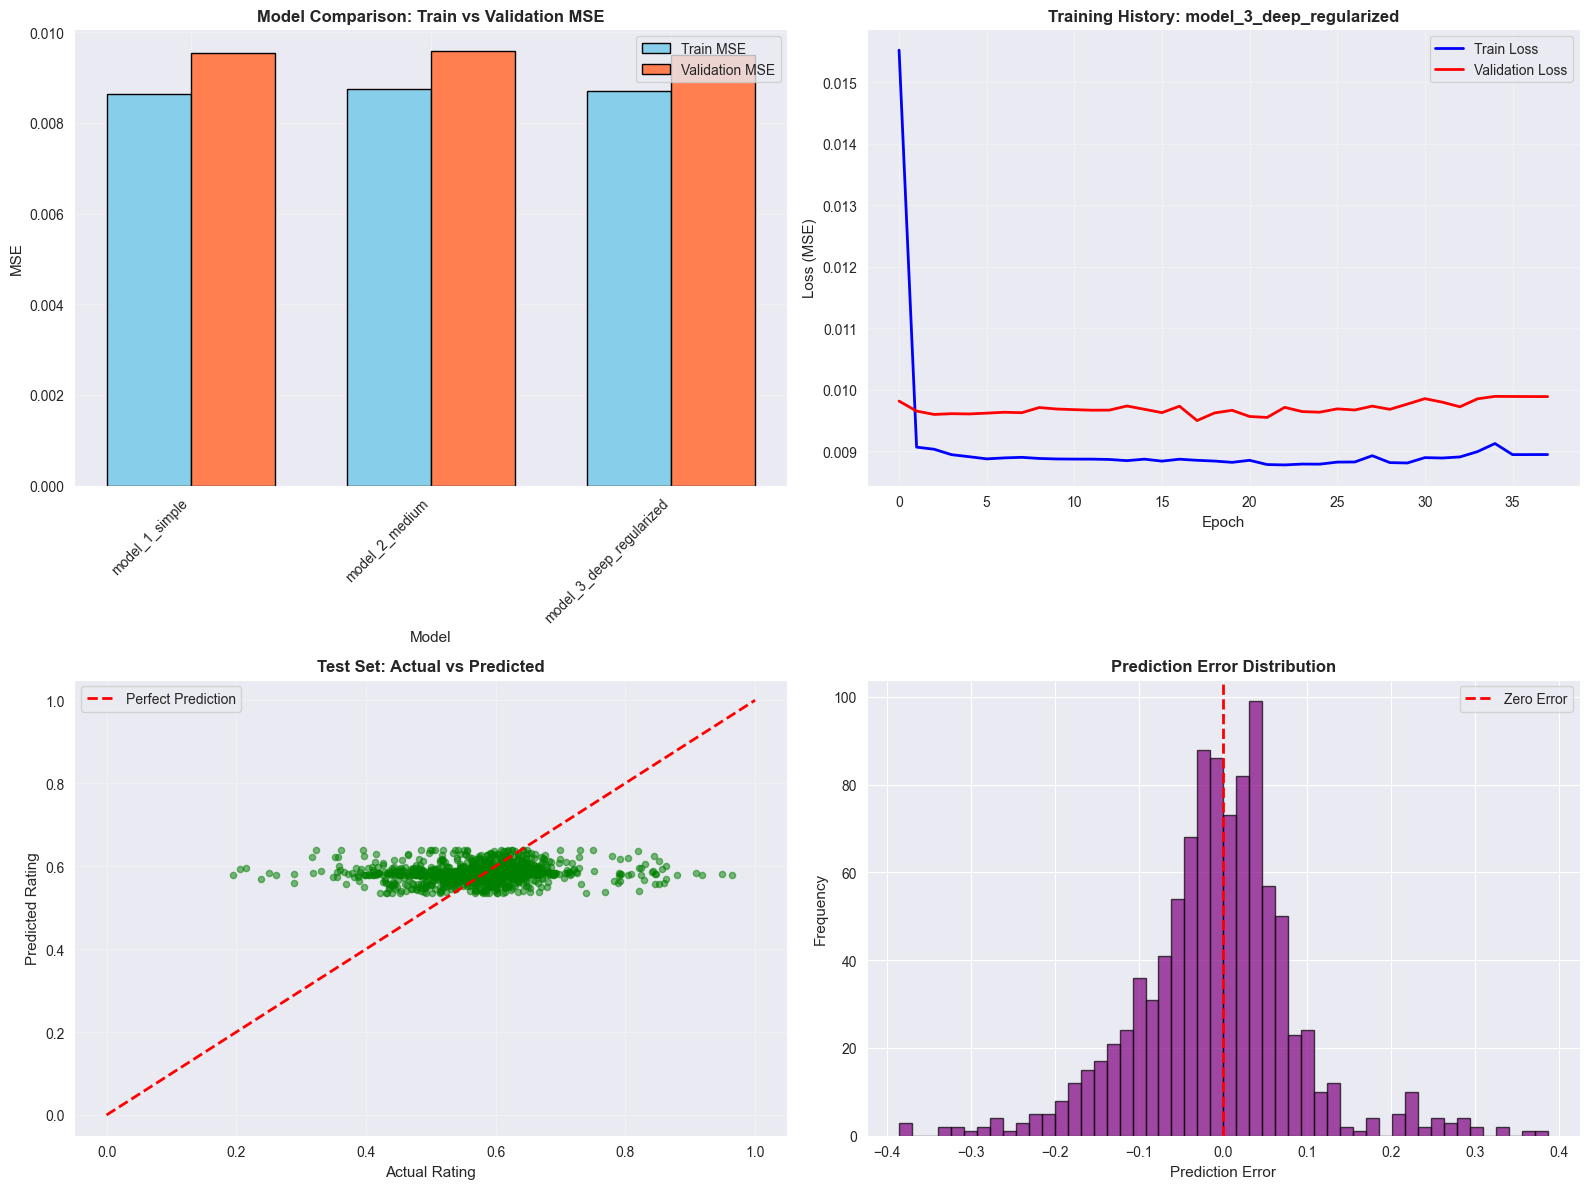


✓ Visualizations complete!


In [16]:
neural_rec = NeuralRecommender(use_interaction_features=True)
metrics = neural_rec.train(interactions_df_complex)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

class MusicRecommender:
    
    def __init__(self, df):
        self.df = df.copy()
        self.features = ['danceability', 'energy', 'valence', 'acousticness', 
                        'instrumentalness', 'speechiness', 'tempo', 'loudness']
        self.scaler = StandardScaler()
        self.prepare_data()
    
    def prepare_data(self):
        self.df['tempo_normalized'] = self.df['tempo'] / 200.0
        self.df['loudness_normalized'] = (self.df['loudness'] + 60) / 60.0
        
        feature_cols = ['danceability', 'energy', 'valence', 'acousticness', 
                       'instrumentalness', 'speechiness', 'tempo_normalized', 
                       'loudness_normalized']
        
        self.feature_matrix = self.df[feature_cols].fillna(0)
        self.feature_matrix_scaled = self.scaler.fit_transform(self.feature_matrix)
        
        print("Content-based recommender data prepared!")
        print(f"  Songs in database: {len(self.df):,}")
        print(f"  Features used: {len(feature_cols)}")
    
    def get_recommendations(self, song_name=None, song_idx=None, n_recommendations=10, 
                           genre_filter=None):
       
        if song_name:
            matches = self.df[self.df['track_name'].str.contains(song_name, case=False, na=False)]
            if len(matches) == 0:
                print(f"Song '{song_name}' not found!")
                print("   Try searching with fewer words or check spelling.")
                return None
            song_idx = matches.index[0]
            print(f"Found: '{matches.iloc[0]['track_name']}' by {matches.iloc[0]['artists']}")
        
        song_features = self.feature_matrix_scaled[song_idx].reshape(1, -1)
        similarities = cosine_similarity(song_features, self.feature_matrix_scaled)[0]
        
        similar_indices = similarities.argsort()[::-1][1:n_recommendations+100]
        
        if genre_filter:
            filtered_indices = [idx for idx in similar_indices 
                              if self.df.iloc[idx]['track_genre'] == genre_filter]
            similar_indices = filtered_indices[:n_recommendations]
        else:
            similar_indices = similar_indices[:n_recommendations]
        
        recommendations = self.df.iloc[similar_indices][
            ['track_name', 'artists', 'track_genre', 'popularity', 
             'danceability', 'energy', 'valence']
        ].copy()
        recommendations['similarity_score'] = similarities[similar_indices]
        return recommendations


recommender = MusicRecommender(df)

Content-based recommender data prepared!
  Songs in database: 114,000
  Features used: 8


In [20]:
test_recs = recommender.get_recommendations(
    song_name="Shape of You",
    n_recommendations=5
)
if test_recs is not None:
    print("\nTop 5 Similar Songs:")
    print(test_recs[['track_name', 'artists', 'similarity_score']])

Found: 'Shape Of You' by Andrew Foy

Top 5 Similar Songs:
                                              track_name  \
39045  Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...   
16096  Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...   
39093  Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...   
16040  Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...   
16078  Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...   

                                                 artists  similarity_score  
39045  Johann Sebastian Bach;Berliner Philharmoniker;...          0.980478  
16096  Johann Sebastian Bach;Berliner Philharmoniker;...          0.980478  
39093  Johann Sebastian Bach;Berliner Philharmoniker;...          0.980478  
16040  Johann Sebastian Bach;Berliner Philharmoniker;...          0.980478  
16078  Johann Sebastian Bach;Berliner Philharmoniker;...          0.980478  


In [21]:
class HybridRecommender:
    def __init__(self, content_recommender, neural_recommender, df):
        self.content_rec = content_recommender
        self.neural_rec = neural_recommender
        self.df = df
        
        print("Hybrid Recommender initialized!")
        print("  - Content-based filtering: Finds similar songs")
        print("  - Neural network: Predicts user ratings")
    
    def get_hybrid_recommendations(self, song_name, n_recommendations=10, 
                                   use_neural=True, weight_content=0.5):
        
        print(f"Finding recommendations for: '{song_name}'")
        
        content_recs = self.content_rec.get_recommendations(
            song_name=song_name,
            n_recommendations=n_recommendations * 3
        )
        
        if content_recs is None:
            return None
        
        print(f"Found {len(content_recs)} similar songs using content-based filtering")
        
        if not use_neural:
            return content_recs.head(n_recommendations)
        
        ratings = []
        for idx in content_recs.index:
            song = self.df.loc[idx]
            song_features = [
                song['danceability'],
                song['energy'],
                song['valence'],
                song['acousticness'],
                song['instrumentalness'],
                song['speechiness'],
                song['tempo'] / 200.0,
                (song['loudness'] + 60) / 60.0,

                song['energy'] * song['danceability'],
                song['acousticness'] / (song['energy'] + 0.01),
                song['valence'] * song['energy'],
                song['acousticness'] * (1 - song['energy'])
            ]
            
            predicted_rating = self.neural_rec.predict_rating(song_features)
            ratings.append(predicted_rating)
        
        content_recs['nn_rating'] = ratings
        
        weight_neural = 1 - weight_content
        
        content_recs['hybrid_score'] = (
            weight_content * content_recs['similarity_score'] +
            weight_neural * content_recs['nn_rating']
        )
        
        print(f"Combined scores (Content: {weight_content:.0%}, Neural: {weight_neural:.0%})")
        
        final_recs = content_recs.nlargest(n_recommendations, 'hybrid_score')
        print(f"Selected top {n_recommendations} recommendations\n")
        
        return final_recs
    
    def display_recommendations(self, recommendations, show_features=False):        
        if recommendations is None or len(recommendations) == 0:
            print("No recommendations found.")
            return
        
        print(f"{'#':<4} {'Song':<35} {'Artist':<25} {'Genre':<15} {'Score':<8}")
        
        for i, (idx, row) in enumerate(recommendations.iterrows(), 1):
            song_name = str(row['track_name'])[:33]
            artist = str(row['artists'])[:23]
            genre = str(row.get('track_genre', 'N/A'))[:13]
            
            if 'hybrid_score' in row:
                score = row['hybrid_score']
            elif 'similarity_score' in row:
                score = row['similarity_score']
            else:
                score = 0
            
            print(f"{i:<4} {song_name:<35} {artist:<25} {genre:<15} {score:.3f}")
            
            if show_features:
                print(f"     Energy: {row['energy']:.2f} | "
                      f"Dance: {row['danceability']:.2f} | "
                      f"Valence: {row['valence']:.2f}")
                if 'nn_rating' in row:
                    print(f"     Content Similarity: {row['similarity_score']:.3f} | "
                          f"Neural Network Rating: {row['nn_rating']:.3f}")
                print()
        
        print(f"{'='*90}\n")

In [22]:
hybrid_rec = HybridRecommender(
    content_recommender=recommender,
    neural_recommender=neural_rec,
    df=df
)

print("\nHybrid Recommendation System ready!")

Hybrid Recommender initialized!
  - Content-based filtering: Finds similar songs
  - Neural network: Predicts user ratings

Hybrid Recommendation System ready!


In [23]:
test_song = "Shape of You"

recommendations = hybrid_rec.get_hybrid_recommendations(
    song_name=test_song,
    n_recommendations=10,
    use_neural=True,
    weight_content=0.5
)

hybrid_rec.display_recommendations(recommendations, show_features=True)

Finding recommendations for: 'Shape of You'
Found: 'Shape Of You' by Andrew Foy
Found 30 similar songs using content-based filtering
Combined scores (Content: 50%, Neural: 50%)
Selected top 10 recommendations

#    Song                                Artist                    Genre           Score   
1    Reno Ride                           Clarence White            bluegrass       0.785
     Energy: 0.32 | Dance: 0.50 | Valence: 0.93
     Content Similarity: 0.980 | Neural Network Rating: 0.589

2    La Milonga de Mis Tiempos           Francisco Canaro          tango           0.784
     Energy: 0.37 | Dance: 0.60 | Valence: 0.78
     Content Similarity: 0.979 | Neural Network Rating: 0.589

3    Brandenburg Concerto No. 3 in G,    Johann Sebastian Bach;B   german          0.783
     Energy: 0.30 | Dance: 0.51 | Valence: 0.80
     Content Similarity: 0.980 | Neural Network Rating: 0.585

4    Brandenburg Concerto No. 3 in G,    Johann Sebastian Bach;B   classical       0.783
     Ener

In [24]:
test_songs = ["Bohemian Rhapsody", "Blinding Lights", "Someone Like You"]

for song in test_songs:
    print(f"TESTING: {song}")
    
    recommendations = hybrid_rec.get_hybrid_recommendations(
        song_name=song,
        n_recommendations=5,
        use_neural=True,
        weight_content=0.5
    )
    
    if recommendations is not None:
        hybrid_rec.display_recommendations(recommendations, show_features=True)

TESTING: Bohemian Rhapsody
Finding recommendations for: 'Bohemian Rhapsody'
Found: 'Bohemian Rhapsody - Acoustic' by John Adams
Found 15 similar songs using content-based filtering
Combined scores (Content: 50%, Neural: 50%)
Selected top 5 recommendations

#    Song                                Artist                    Genre           Score   
1    Lava                                Kuana Torres Kahele;Nap   guitar          0.785
     Energy: 0.21 | Dance: 0.48 | Valence: 0.43
     Content Similarity: 0.992 | Neural Network Rating: 0.579

2    Corazón Apasionado                  Cuco Sánchez              guitar          0.785
     Energy: 0.14 | Dance: 0.48 | Valence: 0.36
     Content Similarity: 0.993 | Neural Network Rating: 0.577

3    情若無花不結果                             張德蘭                       opera           0.784
     Energy: 0.23 | Dance: 0.47 | Valence: 0.36
     Content Similarity: 0.993 | Neural Network Rating: 0.574

4    情若無花不結果                             張德蘭       

In [25]:
test_song = "Uptown Funk"
print("COMPARISON: Content-Based vs Hybrid")

print("\n🔹 CONTENT-BASED ONLY (Pure Audio Similarity):\n")
content_only = hybrid_rec.get_hybrid_recommendations(
    song_name=test_song,
    n_recommendations=5,
    use_neural=False  
)
if content_only is not None:
    hybrid_rec.display_recommendations(content_only)

print("\n🔹 HYBRID (Similarity + Neural Network Prediction):\n")
hybrid_recs = hybrid_rec.get_hybrid_recommendations(
    song_name=test_song,
    n_recommendations=5,
    use_neural=True,  
    weight_content=0.5
)
if hybrid_recs is not None:
    hybrid_rec.display_recommendations(hybrid_recs, show_features=True)

print("Notice: Hybrid recommendations balance similarity with predicted user preference!")

COMPARISON: Content-Based vs Hybrid

🔹 CONTENT-BASED ONLY (Pure Audio Similarity):

Finding recommendations for: 'Uptown Funk'
Found: 'Uptown Funk - From "Alvin And The Chipmunks: The Road Chip" Soundtrack' by Alvin & The Chipmunks
Found 15 similar songs using content-based filtering
#    Song                                Artist                    Genre           Score   
1    Rice & Peas                         Chi Ching Ching           j-dance         0.984
2    CASE 143                            Stray Kids                k-pop           0.982
3    MARCELINE                           Lil God Dan               sad             0.978
4    El Diablo                           Jerry Di                  latino          0.974
5    El Diablo                           Jerry Di                  reggae          0.974


🔹 HYBRID (Similarity + Neural Network Prediction):

Finding recommendations for: 'Uptown Funk'
Found: 'Uptown Funk - From "Alvin And The Chipmunks: The Road Chip" Soundtrack' b

In [26]:
test_song = "Thriller"

weights = [
    (0.8, 0.2, "Favor Similarity"),
    (0.5, 0.5, "Balanced"),
    (0.2, 0.8, "Favor Neural Network")
]

for content_weight, neural_weight, description in weights:
    print(f"⚖️  {description} (Content: {content_weight:.0%}, Neural: {neural_weight:.0%})")    
    recommendations = hybrid_rec.get_hybrid_recommendations(
        song_name=test_song,
        n_recommendations=3,
        use_neural=True,
        weight_content=content_weight
    )
    
    if recommendations is not None:
        for i, (idx, row) in enumerate(recommendations.iterrows(), 1):
            print(f"{i}. {row['track_name'][:40]} - Score: {row['hybrid_score']:.3f}")
        print()

⚖️  Favor Similarity (Content: 80%, Neural: 20%)
Finding recommendations for: 'Thriller'
Found: 'Give us your money (feat. Superthriller)' by Los Amigos Invisibles;Superthriller
Found 9 similar songs using content-based filtering
Combined scores (Content: 80%, Neural: 20%)
Selected top 3 recommendations

1. Let Jesus Row - Score: 0.906
2. Mega Medley - Score: 0.903
3. Should I Stay or Should I Go - Remastere - Score: 0.902

⚖️  Balanced (Content: 50%, Neural: 50%)
Finding recommendations for: 'Thriller'
Found: 'Give us your money (feat. Superthriller)' by Los Amigos Invisibles;Superthriller
Found 9 similar songs using content-based filtering
Combined scores (Content: 50%, Neural: 50%)
Selected top 3 recommendations

1. Let Jesus Row - Score: 0.784
2. Mega Medley - Score: 0.783
3. Condo - Score: 0.782

⚖️  Favor Neural Network (Content: 20%, Neural: 80%)
Finding recommendations for: 'Thriller'
Found: 'Give us your money (feat. Superthriller)' by Los Amigos Invisibles;Superthriller
Found

In [28]:
neural_rec.save_model('models/neural_recommender')

import joblib
joblib.dump(recommender, 'models/content_recommender.pkl')

print("\nAll models saved!")
print("  - Neural network: models/neural_recommender.keras")
print("  - Content recommender: models/content_recommender.pkl")

✓ Model saved to models/neural_recommender.keras
✓ Scaler saved to models/neural_recommender_scaler.pkl

All models saved!
  - Neural network: models/neural_recommender.keras
  - Content recommender: models/content_recommender.pkl
